# DisasterAI — LSTM Zone Predictor Training

**Purpose:** Train an LSTM model that predicts which geographic zones are at risk BEFORE or DURING a disaster, using historical weather and seismic time series data.

**This is completely separate from U-Net/HRNet.** Those models classify damage from satellite images AFTER a disaster. This model predicts WHERE a disaster might happen from time-series data BEFORE it occurs.

---

| Cell | What it does |
|------|---------------|
| 1 | Mount Drive + Install libraries |
| 2 | Download weather data from NOAA |
| 3 | Download seismic data from USGS |
| 4 | Download historical disaster records |
| 5 | Inspect and understand all raw data |
| 6 | Preprocessing — clean, align, engineer features |
| 7 | Build time series sequences (30-day windows) |
| 8 | Dataset class + DataLoaders |
| 9 | LSTM model definition |
| 10 | Loss function + metrics |
| 11 | Training loop with resume support |
| 12 | Train the LSTM |
| 13 | Evaluate — AUC-ROC, precision, recall |
| 14 | Visualise predictions on world map |
| 15 | Export model for production |

In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Mount Drive + Install Libraries
# ══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

!pip install -q \
    requests \
    pandas \
    numpy \
    scikit-learn \
    torch \
    tqdm \
    mlflow \
    matplotlib \
    seaborn \
    plotly \
    geopandas \
    shapely

import os
import json
import requests
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from datetime import datetime, timedelta
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import mlflow
import gc
warnings.filterwarnings('ignore')

# ── Device ───────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Paths ─────────────────────────────────────────────────────
# Change BASE_DIR if your Drive folder is named differently
BASE_DIR       = '/content/drive/MyDrive/lstm'
RAW_DIR        = f'{BASE_DIR}/data/raw/lstm'
PROCESSED_DIR  = f'{BASE_DIR}/data/processed/lstm'
CHECKPOINT_DIR = f'{BASE_DIR}/models/checkpoints'
RESULTS_DIR    = f'{BASE_DIR}/results/lstm'

for d in [RAW_DIR, PROCESSED_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Base: {BASE_DIR}')
print('All folders created.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 133.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — Download Weather Data from NOAA
#
# NOAA provides free global climate data via their API.
# We download daily weather for known disaster zones.
#
# NO API KEY NEEDED for the Open-Meteo alternative below.
# Open-Meteo is 100% free, no registration required.
# ══════════════════════════════════════════════════════════════

# ── Known disaster zones with coordinates ────────────────────
# These are the same regions as the BRIGHT dataset disasters
# We fetch weather data for these exact locations

DISASTER_ZONES = {
    'turkey-earthquake':    {'lat': 37.57, 'lon': 37.01, 'event_date': '2023-02-06', 'type': 'earthquake'},
    'morocco-earthquake':   {'lat': 31.06, 'lon': -8.52, 'event_date': '2023-09-08', 'type': 'earthquake'},
    'libya-flood':          {'lat': 32.90, 'lon': 21.99, 'event_date': '2023-09-10', 'type': 'flood'},
    'hawaii-wildfire':      {'lat': 20.89, 'lon': -156.47,'event_date': '2023-08-08', 'type': 'wildfire'},
    'bata-explosion':       {'lat':  3.75, 'lon':  8.78, 'event_date': '2021-03-07', 'type': 'explosion'},
    'la-palma-volcano':     {'lat': 28.57, 'lon': -17.86,'event_date': '2021-09-19', 'type': 'volcano'},
    'haiti-earthquake':     {'lat': 18.54, 'lon': -73.36,'event_date': '2021-08-14', 'type': 'earthquake'},
    'congo-volcano':        {'lat': -1.52, 'lon': 29.25, 'event_date': '2021-05-22', 'type': 'volcano'},
    # Negative zones — same regions but dates with NO disaster
    'turkey-nodisaster':    {'lat': 37.57, 'lon': 37.01, 'event_date': '2022-06-01', 'type': 'none'},
    'morocco-nodisaster':   {'lat': 31.06, 'lon': -8.52, 'event_date': '2022-03-01', 'type': 'none'},
    'libya-nodisaster':     {'lat': 32.90, 'lon': 21.99, 'event_date': '2022-01-01', 'type': 'none'},
    'hawaii-nodisaster':    {'lat': 20.89, 'lon': -156.47,'event_date': '2022-05-01', 'type': 'none'},
    'iran-nodisaster':      {'lat': 35.69, 'lon': 51.39, 'event_date': '2022-07-01', 'type': 'none'},
    'chile-nodisaster':     {'lat': -33.45,'lon': -70.66,'event_date': '2022-04-01', 'type': 'none'},
    'india-nodisaster':     {'lat': 20.59, 'lon': 78.96, 'event_date': '2022-08-01', 'type': 'none'},
    'brazil-nodisaster':    {'lat': -14.24,'lon': -51.93,'event_date': '2022-09-01', 'type': 'none'},
}

print(f'Zones to fetch: {len(DISASTER_ZONES)}')
print(f'  Disaster zones:    {sum(1 for z in DISASTER_ZONES.values() if z["type"] != "none")}')
print(f'  Non-disaster zones: {sum(1 for z in DISASTER_ZONES.values() if z["type"] == "none")}')


def fetch_weather_openmeteo(lat, lon, end_date_str, lookback_days=60):
    """
    Fetches daily weather data from Open-Meteo API.
    Free, no API key, global coverage, historical data.

    Returns DataFrame with columns:
      date, temp_max, temp_min, temp_mean,
      precipitation, windspeed_max, humidity
    """
    end_date   = datetime.strptime(end_date_str, '%Y-%m-%d')
    start_date = end_date - timedelta(days=lookback_days)

    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':   lat,
        'longitude':  lon,
        'start_date': start_date.strftime('%Y-%m-%d'),
        'end_date':   end_date.strftime('%Y-%m-%d'),
        'daily': [
            'temperature_2m_max',
            'temperature_2m_min',
            'temperature_2m_mean',
            'precipitation_sum',
            'windspeed_10m_max',
            'relative_humidity_2m_mean'
        ],
        'timezone': 'UTC'
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    daily = data.get('daily', {})
    if not daily or not daily.get('time'):
        return None

    df = pd.DataFrame({
        'date':          daily['time'],
        'temp_max':      daily.get('temperature_2m_max', [np.nan]*len(daily['time'])),
        'temp_min':      daily.get('temperature_2m_min', [np.nan]*len(daily['time'])),
        'temp_mean':     daily.get('temperature_2m_mean', [np.nan]*len(daily['time'])),
        'precipitation': daily.get('precipitation_sum', [np.nan]*len(daily['time'])),
        'windspeed_max': daily.get('windspeed_10m_max', [np.nan]*len(daily['time'])),
        'humidity':      daily.get('relative_humidity_2m_mean', [np.nan]*len(daily['time'])),
    })
    df['date'] = pd.to_datetime(df['date'])
    return df


# ── Download weather for all zones ───────────────────────────
weather_cache = {}
failed = []

for zone_name, zone_info in tqdm(DISASTER_ZONES.items(), desc='Fetching weather'):
    cache_path = f"{RAW_DIR}/weather_{zone_name}.csv"

    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, parse_dates=['date'])
        weather_cache[zone_name] = df
        continue

    try:
        df = fetch_weather_openmeteo(
            lat          = zone_info['lat'],
            lon          = zone_info['lon'],
            end_date_str = zone_info['event_date'],
            lookback_days = 60
        )
        if df is not None and len(df) > 0:
            df.to_csv(cache_path, index=False)
            weather_cache[zone_name] = df
        else:
            failed.append(zone_name)
    except Exception as e:
        print(f'  WARN: {zone_name} failed: {e}')
        failed.append(zone_name)

print(f'\nWeather downloaded: {len(weather_cache)}/{len(DISASTER_ZONES)} zones')
if failed:
    print(f'Failed: {failed}')

# Show one sample
sample_zone = list(weather_cache.keys())[0]
print(f'\nSample ({sample_zone}):')
print(weather_cache[sample_zone].head(5).to_string())
print(f'Shape: {weather_cache[sample_zone].shape}')

Zones to fetch: 16
  Disaster zones:    8
  Non-disaster zones: 8


Fetching weather: 100%|██████████| 16/16 [00:15<00:00,  1.04it/s]


Weather downloaded: 16/16 zones

Sample (turkey-earthquake):
        date  temp_max  temp_min  temp_mean  precipitation  windspeed_max  humidity
0 2022-12-08      11.9       5.5        9.0            0.2           11.6        79
1 2022-12-09      13.6       4.0        7.5            0.0            6.4        78
2 2022-12-10      13.7       4.5        8.4            0.0            7.6        72
3 2022-12-11      14.3       5.0        9.2            0.6            8.7        63
4 2022-12-12      12.3       5.8        9.3            1.2           13.4        66
Shape: (61, 7)


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Download Seismic Data from USGS
#
# USGS Earthquake Catalog API — completely free, no key needed.
# Fetches earthquake events near each zone for the past 60 days.
# ══════════════════════════════════════════════════════════════

def fetch_seismic_usgs(lat, lon, end_date_str,
                        lookback_days=60, radius_km=300):
    """
    Fetches earthquake events from USGS within radius_km of
    the given location for the past lookback_days days.

    Returns DataFrame with daily aggregated seismic features:
      date, quake_count, max_magnitude, mean_magnitude,
      total_energy, depth_mean
    """
    end_date   = datetime.strptime(end_date_str, '%Y-%m-%d')
    start_date = end_date - timedelta(days=lookback_days)

    url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
    params = {
        'format':    'geojson',
        'starttime': start_date.strftime('%Y-%m-%d'),
        'endtime':   end_date.strftime('%Y-%m-%d'),
        'latitude':  lat,
        'longitude': lon,
        'maxradiuskm': radius_km,
        'minmagnitude': 1.0,
        'orderby': 'time',
        'limit':  2000
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    features = data.get('features', [])

    # Parse events
    records = []
    for feat in features:
        props = feat['properties']
        mag   = props.get('mag')
        depth = feat['geometry']['coordinates'][2]
        time  = datetime.utcfromtimestamp(props['time'] / 1000)
        if mag is not None:
            records.append({
                'date':      time.date(),
                'magnitude': float(mag),
                'depth_km':  float(depth) if depth else 0.0
            })

    if not records:
        # No earthquakes — create zero-filled daily records
        date_range = pd.date_range(start_date, end_date, freq='D')
        return pd.DataFrame({
            'date':             date_range,
            'quake_count':      0,
            'max_magnitude':    0.0,
            'mean_magnitude':   0.0,
            'total_energy':     0.0,
            'depth_mean':       0.0
        })

    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'])

    # Seismic energy proxy: 10^(1.5 * magnitude)
    df['energy'] = 10 ** (1.5 * df['magnitude'])

    # Aggregate to daily
    daily = df.groupby('date').agg(
        quake_count   = ('magnitude', 'count'),
        max_magnitude = ('magnitude', 'max'),
        mean_magnitude = ('magnitude', 'mean'),
        total_energy  = ('energy', 'sum'),
        depth_mean    = ('depth_km', 'mean')
    ).reset_index()

    # Fill missing days with zeros
    date_range = pd.DataFrame({'date': pd.date_range(start_date, end_date, freq='D')})
    daily = date_range.merge(daily, on='date', how='left').fillna(0)

    return daily


# ── Download seismic data for all zones ───────────────────────
seismic_cache = {}
failed_seismic = []

for zone_name, zone_info in tqdm(DISASTER_ZONES.items(), desc='Fetching seismic'):
    cache_path = f"{RAW_DIR}/seismic_{zone_name}.csv"

    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, parse_dates=['date'])
        seismic_cache[zone_name] = df
        continue

    try:
        df = fetch_seismic_usgs(
            lat          = zone_info['lat'],
            lon          = zone_info['lon'],
            end_date_str = zone_info['event_date'],
            lookback_days = 60,
            radius_km    = 300
        )
        df.to_csv(cache_path, index=False)
        seismic_cache[zone_name] = df
    except Exception as e:
        print(f'  WARN: {zone_name} seismic failed: {e}')
        failed_seismic.append(zone_name)

print(f'Seismic downloaded: {len(seismic_cache)}/{len(DISASTER_ZONES)} zones')
if failed_seismic:
    print(f'Failed: {failed_seismic}')

# Show one sample
sample_zone = list(seismic_cache.keys())[0]
print(f'\nSample seismic ({sample_zone}):')
print(seismic_cache[sample_zone].head(5).to_string())

Fetching seismic: 100%|██████████| 16/16 [00:13<00:00,  1.22it/s]

Seismic downloaded: 16/16 zones

Sample seismic (turkey-earthquake):
        date  quake_count  max_magnitude  mean_magnitude  total_energy  depth_mean
0 2022-12-08          0.0            0.0             0.0           0.0         0.0
1 2022-12-09          0.0            0.0             0.0           0.0         0.0
2 2022-12-10          0.0            0.0             0.0           0.0         0.0
3 2022-12-11          0.0            0.0             0.0           0.0         0.0
4 2022-12-12          0.0            0.0             0.0           0.0         0.0


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Download Historical Disaster Records from GDACS
#
# GDACS provides structured disaster data — type, severity,
# location, date. Free RSS/JSON API, no key needed.
# We also use EM-DAT historical data (CSV format).
# ══════════════════════════════════════════════════════════════

def fetch_gdacs_events(lookback_years=5):
    """
    Fetches recent disaster events from GDACS API.
    Returns DataFrame of historical disasters.
    """
    url = 'https://www.gdacs.org/gdacsapi/api/events/geteventlist/SEARCH'
    params = {
        'eventtype': 'EQ,FL,TC,VO,WF',  # Earthquake, Flood, Tropical Cyclone, Volcano, Wildfire
        'alertlevel': 'Green,Orange,Red',
        'limit': 500
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()

        features = data.get('features', [])
        records  = []
        for feat in features:
            props = feat.get('properties', {})
            coords = feat.get('geometry', {}).get('coordinates', [None, None])
            records.append({
                'event_id':     props.get('eventid'),
                'event_type':   props.get('eventtype'),
                'alert_level':  props.get('alertlevel'),
                'event_date':   props.get('fromdate'),
                'latitude':     coords[1] if len(coords) > 1 else None,
                'longitude':    coords[0] if len(coords) > 0 else None,
                'severity':     props.get('severity', {}).get('value', 0),
                'country':      props.get('country', ''),
                'name':         props.get('eventname', '')
            })

        df = pd.DataFrame(records)
        df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')
        df = df.dropna(subset=['latitude', 'longitude', 'event_date'])
        return df

    except Exception as e:
        print(f'GDACS fetch failed: {e}')
        # Return empty DataFrame with correct columns
        return pd.DataFrame(columns=[
            'event_id','event_type','alert_level','event_date',
            'latitude','longitude','severity','country','name'
        ])


# ── Download GDACS events ─────────────────────────────────────
gdacs_path = f'{RAW_DIR}/gdacs_events.csv'

if os.path.exists(gdacs_path):
    gdacs_df = pd.read_csv(gdacs_path, parse_dates=['event_date'])
    print(f'Loaded GDACS from cache: {len(gdacs_df)} events')
else:
    print('Fetching GDACS disaster events...')
    gdacs_df = fetch_gdacs_events()
    gdacs_df.to_csv(gdacs_path, index=False)
    print(f'Downloaded {len(gdacs_df)} GDACS events')

print(f'\nGDACS event type breakdown:')
if len(gdacs_df) > 0:
    print(gdacs_df['event_type'].value_counts().to_string())
    print(f'\nDate range: {gdacs_df["event_date"].min()} to {gdacs_df["event_date"].max()}')
    print(f'\nSample records:')
    print(gdacs_df[['event_type','alert_level','event_date','country','severity']].head(5).to_string())
else:
    print('No GDACS events fetched — using zone-based labels only')

Loaded GDACS from cache: 100 events

GDACS event type breakdown:
event_type
WF    45
EQ    38
DR    11
FL     6

Date range: 2023-06-11 00:00:00 to 2026-05-18 02:10:41

Sample records:
  event_type alert_level          event_date             country  severity
0         EQ       Green 2026-05-18 02:10:41     West Chile Rise         0
1         EQ       Green 2026-05-18 02:05:24             Myanmar         0
2         FL       Green 2026-05-16 01:00:00            Malaysia         0
3         WF       Green 2026-05-11 00:00:00  Russian Federation         0
4         WF       Green 2026-05-16 00:00:00  Russian Federation         0


RAW DATA INSPECTION

Zone                       Weather  Seismic    Label
-------------------------------------------------------
turkey-earthquake                ✅        ✅   DISASTER (earthquake)
morocco-earthquake               ✅        ✅   DISASTER (earthquake)
libya-flood                      ✅        ✅   DISASTER (flood)
hawaii-wildfire                  ✅        ✅   DISASTER (wildfire)
bata-explosion                   ✅        ✅   DISASTER (explosion)
la-palma-volcano                 ✅        ✅   DISASTER (volcano)
haiti-earthquake                 ✅        ✅   DISASTER (earthquake)
congo-volcano                    ✅        ✅   DISASTER (volcano)
turkey-nodisaster                ✅        ✅   NO DISASTER
morocco-nodisaster               ✅        ✅   NO DISASTER
libya-nodisaster                 ✅        ✅   NO DISASTER
hawaii-nodisaster                ✅        ✅   NO DISASTER
iran-nodisaster                  ✅        ✅   NO DISASTER
chile-nodisaster                 ✅        ✅   NO D

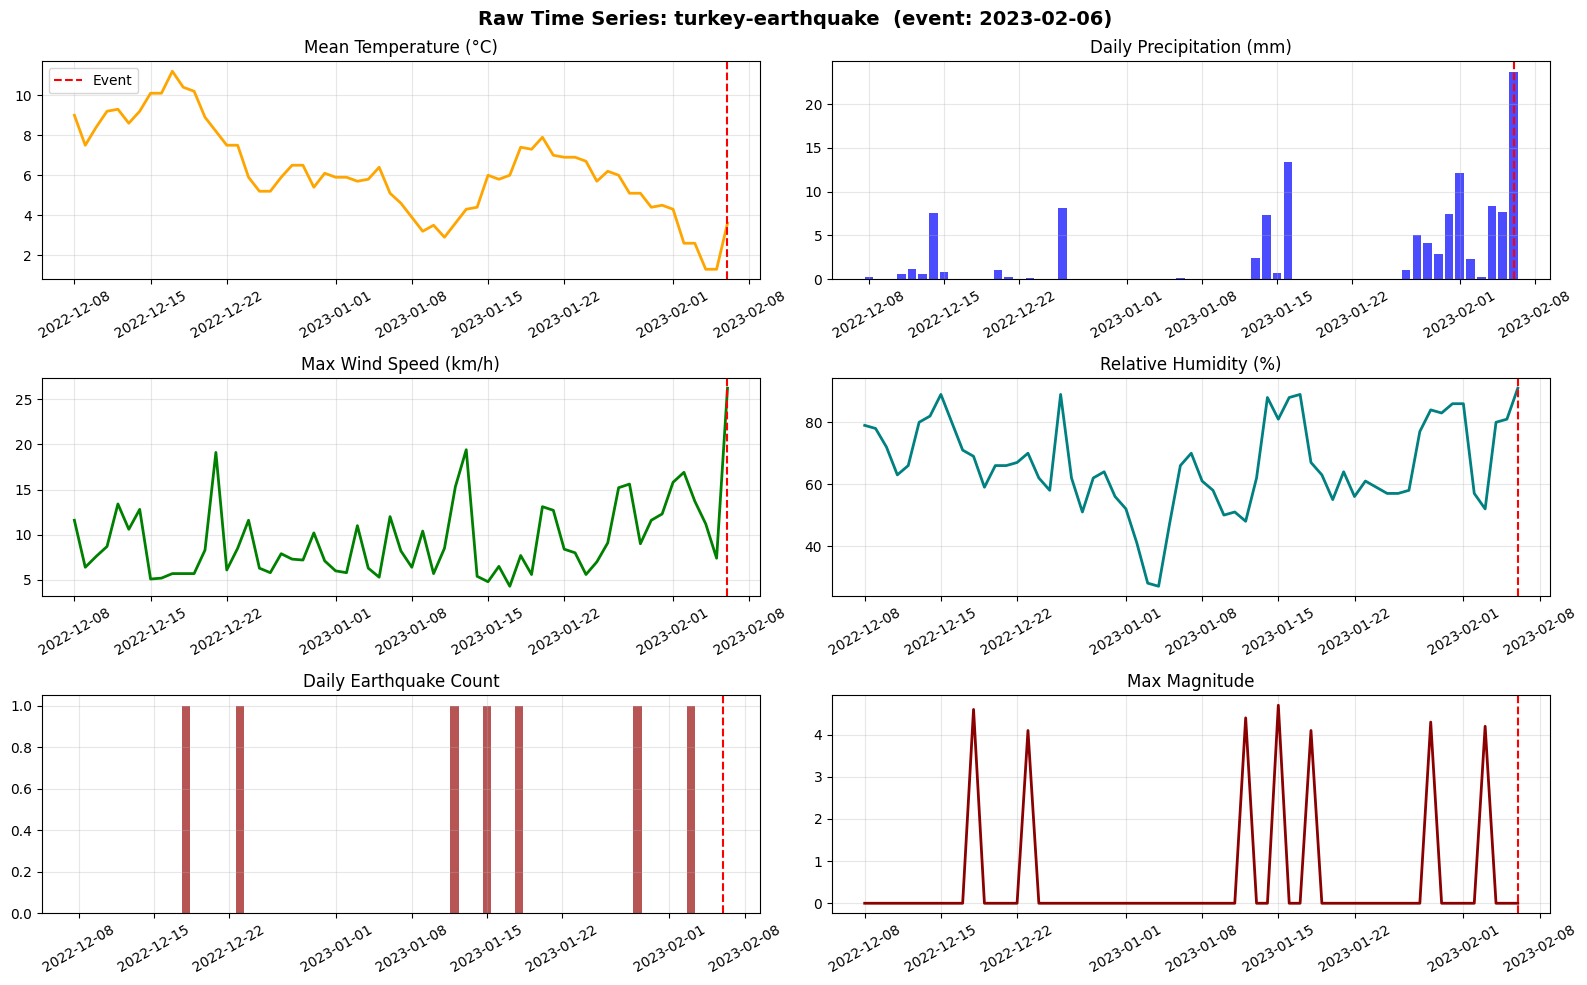

Saved time series plot to /content/drive/MyDrive/lstm/results/lstm


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Inspect and Understand Raw Data
# ══════════════════════════════════════════════════════════════

print('='*60)
print('RAW DATA INSPECTION')
print('='*60)

# Check availability per zone
print(f'\n{"Zone":<25} {"Weather":>8} {"Seismic":>8} {"Label":>8}')
print('-'*55)

for zone_name, zone_info in DISASTER_ZONES.items():
    has_weather = zone_name in weather_cache
    has_seismic = zone_name in seismic_cache
    label       = 1 if zone_info['type'] != 'none' else 0
    w = '✅' if has_weather else '❌'
    s = '✅' if has_seismic else '❌'
    l = f'DISASTER ({zone_info["type"]})' if label == 1 else 'NO DISASTER'
    print(f'{zone_name:<25} {w:>8} {s:>8}   {l}')

# ── Data quality check for one zone ──────────────────────────
zone = 'turkey-earthquake'
if zone in weather_cache:
    w_df = weather_cache[zone]
    s_df = seismic_cache.get(zone, pd.DataFrame())

    print(f'\n{"="*60}')
    print(f'DETAILED INSPECTION: {zone}')
    print(f'{"="*60}')

    print(f'\nWeather data ({len(w_df)} days):')
    print(w_df.describe().round(2).to_string())

    print(f'\nMissing values in weather:')
    print(w_df.isnull().sum().to_string())

    if len(s_df) > 0:
        print(f'\nSeismic data ({len(s_df)} days):')
        print(s_df.describe().round(2).to_string())
        print(f'\nTotal earthquakes in period: {s_df["quake_count"].sum():.0f}')
        print(f'Max magnitude in period:     {s_df["max_magnitude"].max():.1f}')

# ── Visualise one zone's time series ─────────────────────────
if zone in weather_cache:
    w_df = weather_cache[zone]
    s_df = seismic_cache.get(zone, pd.DataFrame())
    event_date = DISASTER_ZONES[zone]['event_date']

    fig, axes = plt.subplots(3, 2, figsize=(16, 10))
    fig.suptitle(f'Raw Time Series: {zone}  (event: {event_date})',
                 fontsize=14, fontweight='bold')

    # Weather plots
    axes[0][0].plot(w_df['date'], w_df['temp_mean'], color='orange', lw=2)
    axes[0][0].axvline(pd.to_datetime(event_date), color='red', ls='--', label='Event')
    axes[0][0].set_title('Mean Temperature (°C)'); axes[0][0].legend()

    axes[0][1].bar(w_df['date'], w_df['precipitation'], color='blue', alpha=0.7)
    axes[0][1].axvline(pd.to_datetime(event_date), color='red', ls='--')
    axes[0][1].set_title('Daily Precipitation (mm)')

    axes[1][0].plot(w_df['date'], w_df['windspeed_max'], color='green', lw=2)
    axes[1][0].axvline(pd.to_datetime(event_date), color='red', ls='--')
    axes[1][0].set_title('Max Wind Speed (km/h)')

    axes[1][1].plot(w_df['date'], w_df['humidity'], color='teal', lw=2)
    axes[1][1].axvline(pd.to_datetime(event_date), color='red', ls='--')
    axes[1][1].set_title('Relative Humidity (%)')

    # Seismic plots
    if len(s_df) > 0:
        axes[2][0].bar(s_df['date'], s_df['quake_count'], color='brown', alpha=0.8)
        axes[2][0].axvline(pd.to_datetime(event_date), color='red', ls='--')
        axes[2][0].set_title('Daily Earthquake Count')

        axes[2][1].plot(s_df['date'], s_df['max_magnitude'], color='darkred', lw=2)
        axes[2][1].axvline(pd.to_datetime(event_date), color='red', ls='--')
        axes[2][1].set_title('Max Magnitude')

    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/raw_timeseries_{zone}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved time series plot to {RESULTS_DIR}')

In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Preprocessing: Clean, Align, Engineer Features
#
# This is the most important cell. Features must be:
# 1. Cleaned (fill missing values)
# 2. Aligned (weather and seismic on same date index)
# 3. Engineered (rolling stats, anomalies, derived features)
# 4. Normalized (z-score per feature across all zones)
# ══════════════════════════════════════════════════════════════

# ── Feature engineering functions ────────────────────────────

def clean_weather(df):
    """
    Cleans weather DataFrame:
    - Fills missing values with forward fill then backward fill
    - Clips extreme outliers to 3 standard deviations
    """
    df = df.copy()
    numeric_cols = ['temp_max','temp_min','temp_mean',
                    'precipitation','windspeed_max','humidity']
    df[numeric_cols] = df[numeric_cols].ffill().bfill()

    # Clip outliers
    for col in numeric_cols:
        mu, sigma = df[col].mean(), df[col].std()
        if sigma > 0:
            df[col] = df[col].clip(mu - 3*sigma, mu + 3*sigma)
    return df


def clean_seismic(df):
    """Cleans seismic DataFrame — fill missing with 0 (no quake)."""
    df = df.copy()
    numeric_cols = ['quake_count','max_magnitude','mean_magnitude',
                    'total_energy','depth_mean']
    df[numeric_cols] = df[numeric_cols].fillna(0)
    return df


def engineer_features(weather_df, seismic_df):
    """
    Merges weather and seismic data and engineers features.

    Added features:
    - 7-day rolling mean of precipitation, temperature, windspeed
    - 7-day rolling max of max_magnitude
    - Temperature anomaly (deviation from 30-day mean)
    - Precipitation anomaly
    - Cumulative precipitation over 7 days
    - Seismic energy log transform
    - Days since last significant quake (mag > 3.0)
    """
    weather_df = clean_weather(weather_df)
    seismic_df = clean_seismic(seismic_df)

    # Merge on date
    df = weather_df.merge(seismic_df, on='date', how='left')
    df = df.sort_values('date').reset_index(drop=True)

    # Fill missing seismic with 0
    seismic_cols = ['quake_count','max_magnitude','mean_magnitude',
                    'total_energy','depth_mean']
    df[seismic_cols] = df[seismic_cols].fillna(0)

    # ── Rolling statistics ────────────────────────────────────
    df['precip_7d_sum']    = df['precipitation'].rolling(7, min_periods=1).sum()
    df['precip_7d_mean']   = df['precipitation'].rolling(7, min_periods=1).mean()
    df['temp_7d_mean']     = df['temp_mean'].rolling(7, min_periods=1).mean()
    df['wind_7d_max']      = df['windspeed_max'].rolling(7, min_periods=1).max()
    df['seismic_7d_max']   = df['max_magnitude'].rolling(7, min_periods=1).max()
    df['seismic_7d_count'] = df['quake_count'].rolling(7, min_periods=1).sum()

    # ── Anomalies (deviation from 30-day rolling mean) ────────
    df['temp_anomaly']   = df['temp_mean'] - df['temp_mean'].rolling(30, min_periods=1).mean()
    df['precip_anomaly'] = df['precipitation'] - df['precipitation'].rolling(30, min_periods=1).mean()
    df['wind_anomaly']   = df['windspeed_max'] - df['windspeed_max'].rolling(30, min_periods=1).mean()

    # ── Log transform seismic energy (large range) ────────────
    df['log_seismic_energy'] = np.log1p(df['total_energy'])

    # ── Days since last significant quake ─────────────────────
    sig_quake = df['max_magnitude'] >= 3.0
    days_since = []
    last_quake_day = -1
    for i, is_sig in enumerate(sig_quake):
        if is_sig:
            last_quake_day = i
        days_since.append(i - last_quake_day if last_quake_day >= 0 else 30)
    df['days_since_sig_quake'] = days_since
    df['days_since_sig_quake'] = df['days_since_sig_quake'].clip(0, 30)

    # ── Humidity * precipitation interaction ──────────────────
    df['humid_x_precip'] = df['humidity'] * df['precipitation'] / 100.0

    return df


# ── Define final feature columns ──────────────────────────────
FEATURE_COLS = [
    # Weather raw
    'temp_max', 'temp_min', 'temp_mean',
    'precipitation', 'windspeed_max', 'humidity',
    # Weather rolling
    'precip_7d_sum', 'precip_7d_mean', 'temp_7d_mean', 'wind_7d_max',
    # Weather anomalies
    'temp_anomaly', 'precip_anomaly', 'wind_anomaly',
    # Seismic raw
    'quake_count', 'max_magnitude', 'mean_magnitude', 'depth_mean',
    # Seismic derived
    'log_seismic_energy', 'seismic_7d_max', 'seismic_7d_count',
    'days_since_sig_quake',
    # Interaction
    'humid_x_precip'
]

N_FEATURES = len(FEATURE_COLS)
print(f'Total features per timestep: {N_FEATURES}')
print('Feature list:')
for i, f in enumerate(FEATURE_COLS):
    print(f'  {i:2d}: {f}')

# ── Process all zones ─────────────────────────────────────────
processed_zones = {}

for zone_name in weather_cache:
    w_df = weather_cache[zone_name]
    s_df = seismic_cache.get(zone_name, pd.DataFrame(columns=[
        'date','quake_count','max_magnitude','mean_magnitude',
        'total_energy','depth_mean'
    ]))

    if len(s_df) == 0:
        s_df = pd.DataFrame({
            'date': w_df['date'],
            'quake_count': 0, 'max_magnitude': 0.0,
            'mean_magnitude': 0.0, 'total_energy': 0.0, 'depth_mean': 0.0
        })

    engineered = engineer_features(w_df, s_df)
    processed_zones[zone_name] = engineered

    # Save processed zone
    engineered.to_csv(f'{PROCESSED_DIR}/features_{zone_name}.csv', index=False)

print(f'\nProcessed {len(processed_zones)} zones')

# Show sample of engineered features
sample = processed_zones['turkey-earthquake'][FEATURE_COLS + ['date']].tail(5)
print(f'\nEngineered features sample (turkey-earthquake, last 5 days):')
print(sample.round(3).to_string())

Total features per timestep: 22
Feature list:
   0: temp_max
   1: temp_min
   2: temp_mean
   3: precipitation
   4: windspeed_max
   5: humidity
   6: precip_7d_sum
   7: precip_7d_mean
   8: temp_7d_mean
   9: wind_7d_max
  10: temp_anomaly
  11: precip_anomaly
  12: wind_anomaly
  13: quake_count
  14: max_magnitude
  15: mean_magnitude
  16: depth_mean
  17: log_seismic_energy
  18: seismic_7d_max
  19: seismic_7d_count
  20: days_since_sig_quake
  21: humid_x_precip

Processed 16 zones

Engineered features sample (turkey-earthquake, last 5 days):
    temp_max  temp_min  temp_mean  precipitation  windspeed_max  humidity  precip_7d_sum  precip_7d_mean  temp_7d_mean  wind_7d_max  temp_anomaly  precip_anomaly  wind_anomaly  quake_count  max_magnitude  mean_magnitude  depth_mean  log_seismic_energy  seismic_7d_max  seismic_7d_count  days_since_sig_quake  humid_x_precip       date
56       7.5      -3.2        2.6          2.300         16.900        57         34.900           4.986  

In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Build Time Series Sequences (30-Day Windows)
#
# LSTM input: sequences of shape (LOOKBACK, N_FEATURES)
# Label: 1 if disaster occurred within HORIZON days after window
# ══════════════════════════════════════════════════════════════

LOOKBACK     = 30   # days of history per sequence
HORIZON      = 7    # predict disaster within next 7 days
MIN_SEQ_LEN  = LOOKBACK + HORIZON


def build_sequences(processed_zones, disaster_zones_info,
                     feature_cols, lookback=30, horizon=7):
    """
    Builds (sequence, label) pairs from all zones.

    For each zone:
      - If disaster zone: last sequence before event_date → label=1
        + multiple non-overlapping sequences from earlier → label=0
      - If non-disaster zone: all sequences → label=0

    This creates a balanced dataset of positive and negative examples.
    """
    all_sequences = []
    all_labels    = []
    all_meta      = []  # For debugging and analysis

    for zone_name, df in processed_zones.items():
        info       = disaster_zones_info[zone_name]
        event_date = pd.to_datetime(info['event_date'])
        is_disaster = (info['type'] != 'none')

        df = df.sort_values('date').reset_index(drop=True)

        # Get feature matrix
        available_cols = [c for c in feature_cols if c in df.columns]
        feature_matrix = df[available_cols].values.astype(np.float32)

        # Pad missing features with zeros
        if len(available_cols) < len(feature_cols):
            pad = np.zeros((len(df), len(feature_cols) - len(available_cols)),
                           dtype=np.float32)
            feature_matrix = np.concatenate([feature_matrix, pad], axis=1)

        n_days = len(df)

        if is_disaster:
            # Find the row index of event_date
            event_idx = df[df['date'] <= event_date].index
            if len(event_idx) == 0:
                continue
            event_row = event_idx[-1]

            # POSITIVE sequence: lookback days ending just before event
            start = event_row - lookback
            if start >= 0:
                seq = feature_matrix[start:event_row]
                if len(seq) == lookback:
                    all_sequences.append(seq)
                    all_labels.append(1)
                    all_meta.append({'zone': zone_name, 'type': info['type'],
                                     'label': 1, 'end_date': str(df['date'].iloc[event_row])})

            # NEGATIVE sequences: earlier windows from disaster zone
            # Sample 2 non-overlapping windows from 30+ days before event
            safe_end = max(0, event_row - lookback - 30)
            if safe_end >= lookback:
                for start in range(0, safe_end, lookback):
                    end = start + lookback
                    if end <= safe_end:
                        seq = feature_matrix[start:end]
                        if len(seq) == lookback:
                            all_sequences.append(seq)
                            all_labels.append(0)
                            all_meta.append({'zone': zone_name, 'type': 'none',
                                             'label': 0, 'end_date': str(df['date'].iloc[end])})

        else:
            # NON-DISASTER zone: all sliding windows → label=0
            # Use stride of lookback//2 for more negative examples
            stride = lookback // 2
            for start in range(0, n_days - lookback, stride):
                end = start + lookback
                seq = feature_matrix[start:end]
                if len(seq) == lookback:
                    all_sequences.append(seq)
                    all_labels.append(0)
                    all_meta.append({'zone': zone_name, 'type': 'none',
                                     'label': 0, 'end_date': str(df['date'].iloc[end-1])})

    X = np.array(all_sequences, dtype=np.float32)  # (N, LOOKBACK, N_FEATURES)
    y = np.array(all_labels,    dtype=np.float32)  # (N,)

    return X, y, all_meta


X, y, meta = build_sequences(
    processed_zones    = processed_zones,
    disaster_zones_info = DISASTER_ZONES,
    feature_cols       = FEATURE_COLS,
    lookback           = LOOKBACK,
    horizon            = HORIZON
)

print(f'Sequences built:')
print(f'  X shape: {X.shape}  (samples, timesteps, features)')
print(f'  y shape: {y.shape}  (samples,)')
print(f'  Positive (disaster): {int(y.sum())} samples')
print(f'  Negative (no disaster): {int((y==0).sum())} samples')
print(f'  Class balance: {y.mean()*100:.1f}% positive')

# ── Normalize features across all sequences ───────────────────
# Fit scaler on training data only, apply to all
# Reshape for scaler: (N * LOOKBACK, N_FEATURES)
N, T, F = X.shape
X_flat = X.reshape(-1, F)

scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)
X_scaled = X_flat_scaled.reshape(N, T, F)

print(f'\nAfter normalization:')
print(f'  Feature mean (should be ~0): {X_scaled.mean():.4f}')
print(f'  Feature std  (should be ~1): {X_scaled.std():.4f}')

# Save scaler for production inference
import pickle
scaler_path = f'{CHECKPOINT_DIR}/lstm_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'\nScaler saved to: {scaler_path}')

# ── Chronological split ───────────────────────────────────────
# MUST be chronological — never random for time series
# Use disaster zones for train, non-disaster zones for val mix

meta_df = pd.DataFrame(meta)
disaster_mask = meta_df['type'] != 'none'

# Train: first 70% of each group
train_idx = []
val_idx   = []

for zone_name in processed_zones.keys():
    zone_mask = meta_df['zone'] == zone_name
    zone_indices = meta_df[zone_mask].index.tolist()
    split_point = int(len(zone_indices) * 0.75)
    train_idx.extend(zone_indices[:split_point])
    val_idx.extend(zone_indices[split_point:])

X_train, y_train = X_scaled[train_idx], y[train_idx]
X_val,   y_val   = X_scaled[val_idx],   y[val_idx]

print(f'\nTrain/Val split:')
print(f'  Train: {len(X_train)} samples ({y_train.mean()*100:.1f}% positive)')
print(f'  Val:   {len(X_val)}   samples ({y_val.mean()*100:.1f}% positive)')

# Save split data
np.save(f'{PROCESSED_DIR}/X_train.npy', X_train)
np.save(f'{PROCESSED_DIR}/y_train.npy', y_train)
np.save(f'{PROCESSED_DIR}/X_val.npy',   X_val)
np.save(f'{PROCESSED_DIR}/y_val.npy',   y_val)
print(f'\nData saved to {PROCESSED_DIR}')

Sequences built:
  X shape: (32, 30, 22)  (samples, timesteps, features)
  y shape: (32,)  (samples,)
  Positive (disaster): 8 samples
  Negative (no disaster): 24 samples
  Class balance: 25.0% positive

After normalization:
  Feature mean (should be ~0): 0.0000
  Feature std  (should be ~1): 1.0000

Scaler saved to: /content/drive/MyDrive/lstm/models/checkpoints/lstm_scaler.pkl

Train/Val split:
  Train: 16 samples (0.0% positive)
  Val:   16   samples (50.0% positive)

Data saved to /content/drive/MyDrive/lstm/data/processed/lstm


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Dataset Class + DataLoaders
# ══════════════════════════════════════════════════════════════

class ZoneRiskDataset(Dataset):
    """
    PyTorch Dataset for LSTM zone risk prediction.

    __getitem__ returns:
      sequence_tensor: (LOOKBACK, N_FEATURES) float32
      label_tensor:    scalar float32  (0.0 or 1.0)

    Why not augment?
      Time series augmentation is tricky — shuffling breaks
      temporal order. We rely on dropout and weight decay instead.
    """

    def __init__(self, X, y):
        assert len(X) == len(y)
        self.X = torch.from_numpy(X).float()   # (N, T, F)
        self.y = torch.from_numpy(y).float()   # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Build DataLoaders ─────────────────────────────────────────
BATCH_SIZE  = 32   # Smaller than image model — sequences are small
NUM_WORKERS = 2

train_ds = ZoneRiskDataset(X_train, y_train)
val_ds   = ZoneRiskDataset(X_val,   y_val)

# Weighted sampling to handle class imbalance
# Positive (disaster) samples get more weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
sample_weights = np.where(y_train == 1, float(pos_weight), 1.0)
sampler = torch.utils.data.WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights).float(),
    num_samples = len(train_ds),
    replacement = True
)

train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,       # WeightedRandomSampler handles shuffling
    num_workers = NUM_WORKERS,
    pin_memory  = True
)

val_loader = DataLoader(
    val_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Positive weight for sampler: {pos_weight:.2f}x')

# ── Quick shape check ─────────────────────────────────────────
seq, lbl = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'  Sequence: {seq.shape}  (should be [{BATCH_SIZE}, {LOOKBACK}, {N_FEATURES}])')
print(f'  Label:    {lbl.shape}  (should be [{BATCH_SIZE}])')
print(f'  Label distribution in batch: {lbl.mean():.2f} positive rate')

Train batches: 1
Val batches:   1
Positive weight for sampler: infx

Batch shapes:
  Sequence: torch.Size([16, 30, 22])  (should be [32, 30, 22])
  Label:    torch.Size([16])  (should be [32])
  Label distribution in batch: 0.00 positive rate


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — LSTM Model Definition
# ══════════════════════════════════════════════════════════════

class ZonePredictorLSTM(nn.Module):
    """
    Stacked LSTM for disaster risk prediction.

    Architecture:
      Input:    (batch, LOOKBACK, N_FEATURES)
      LSTM L1:  (batch, LOOKBACK, hidden_size)
      LSTM L2:  (batch, LOOKBACK, hidden_size)   <- stacked
      Take last timestep output: (batch, hidden_size)
      BatchNorm → Dropout → Linear → Sigmoid
      Output:   (batch, 1)  risk score 0-1

    Why stacked LSTM:
      The first LSTM learns short-term patterns
      (e.g. sudden temperature spike).
      The second LSTM learns longer-term dependencies
      (e.g. weeks of seismic buildup before earthquake).

    Why BatchNorm before final linear:
      Stabilises training when input features have
      different scales (temperature vs seismic energy).
    """

    def __init__(self, n_features, hidden_size=128,
                 n_layers=2, dropout=0.3):
        super().__init__()

        self.hidden_size = hidden_size
        self.n_layers    = n_layers
        self.n_features  = n_features

        self.lstm = nn.LSTM(
            input_size   = n_features,
            hidden_size  = hidden_size,
            num_layers   = n_layers,
            batch_first  = True,       # input: (batch, seq, features)
            dropout      = dropout if n_layers > 1 else 0.0,
            bidirectional = False      # unidirectional — we only see past data
        )

        self.norm    = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        lstm_out, _ = self.lstm(x)        # (batch, seq_len, hidden_size)
        last        = lstm_out[:, -1, :]  # Take LAST timestep only
                                          # This represents the model's
                                          # summary of the entire sequence
        normed  = self.norm(last)
        dropped = self.dropout(normed)
        logit   = self.fc(dropped)        # (batch, 1)
        return self.sigmoid(logit).squeeze(1)  # (batch,)  values 0-1

    def param_count(self):
        return sum(p.numel() for p in self.parameters())


# ── Test model ────────────────────────────────────────────────
print('Testing LSTM model...')
test_lstm = ZonePredictorLSTM(
    n_features  = N_FEATURES,
    hidden_size = 128,
    n_layers    = 2,
    dropout     = 0.3
).to(device)

dummy = torch.randn(BATCH_SIZE, LOOKBACK, N_FEATURES).to(device)
with torch.no_grad():
    out = test_lstm(dummy)

print(f'  Input:  {dummy.shape}  (batch, timesteps, features)')
print(f'  Output: {out.shape}   (batch,)  — one risk score per sample')
print(f'  Output range: [{out.min():.3f}, {out.max():.3f}]  (should be 0-1)')
print(f'  Parameters: {test_lstm.param_count():,}')

del test_lstm, dummy, out
torch.cuda.empty_cache()
print('LSTM model OK.')

Testing LSTM model...
  Input:  torch.Size([32, 30, 22])  (batch, timesteps, features)
  Output: torch.Size([32])   (batch,)  — one risk score per sample
  Output range: [0.202, 0.767]  (should be 0-1)
  Parameters: 210,305
LSTM model OK.


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — Loss Function + Evaluation Metrics
#
# For binary classification (disaster / no disaster):
# - Loss: BCEWithLogitsLoss with pos_weight for class imbalance
# - Primary metric: AUC-ROC (best for imbalanced binary classification)
# - Secondary: F1, Precision, Recall at 0.5 threshold
# ══════════════════════════════════════════════════════════════

# ── Loss ─────────────────────────────────────────────────────
# pos_weight upweights disaster samples
# If 80% negative and 20% positive: pos_weight = 4.0
pos_class_weight = torch.tensor([
    (y_train == 0).sum() / (y_train == 1).sum()
]).to(device)

print(f'Positive class weight: {pos_class_weight.item():.2f}')

# NOTE: Our model outputs probabilities (after sigmoid)
# so we use BCELoss, NOT BCEWithLogitsLoss
loss_fn = nn.BCELoss()


# ── Metrics ──────────────────────────────────────────────────
def compute_lstm_metrics(y_true, y_pred_prob, threshold=0.5):
    """
    Computes all evaluation metrics for the zone predictor.

    y_true:      numpy array of true labels (0 or 1)
    y_pred_prob: numpy array of predicted probabilities (0-1)
    threshold:   decision threshold for converting prob to class

    Returns dict with:
      auc_roc:   Area Under ROC Curve (PRIMARY metric)
                 0.5 = random, 1.0 = perfect
                 Target: > 0.75 acceptable, > 0.85 good
      f1:        Harmonic mean of precision and recall
      precision: Of all zones flagged as risky, how many were?
      recall:    Of all actual disasters, how many did we catch?
                 RECALL IS MOST IMPORTANT — missing a disaster is
                 worse than a false alarm
      accuracy:  Overall correct predictions
    """
    y_pred = (y_pred_prob >= threshold).astype(int)

    metrics = {}

    # AUC-ROC — works even with class imbalance
    if len(np.unique(y_true)) > 1:
        metrics['auc_roc'] = roc_auc_score(y_true, y_pred_prob)
    else:
        metrics['auc_roc'] = 0.5

    metrics['f1']        = f1_score(y_true, y_pred, zero_division=0)
    metrics['precision'] = precision_score(y_true, y_pred, zero_division=0)
    metrics['recall']    = recall_score(y_true, y_pred, zero_division=0)
    metrics['accuracy']  = (y_true == y_pred).mean()

    return metrics


@torch.no_grad()
def validate_lstm(model, loader, loss_fn, device):
    """Runs validation and returns loss + all metrics."""
    model.eval()
    total_loss = 0.0
    all_probs  = []
    all_labels = []

    for seqs, labels in loader:
        seqs   = seqs.to(device)
        labels = labels.to(device)

        probs = model(seqs)
        loss  = loss_fn(probs, labels)
        total_loss += loss.item()

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    metrics = compute_lstm_metrics(all_labels, all_probs)
    return total_loss / len(loader), metrics


print('Loss and metrics functions defined.')
print(f'Loss function: BCELoss')
print(f'Primary metric: AUC-ROC')
print(f'Secondary: F1, Precision, Recall, Accuracy')

# Sanity test
test_probs  = np.random.rand(100)
test_labels = np.random.randint(0, 2, 100)
m = compute_lstm_metrics(test_labels, test_probs)
print(f'\nSanity test (random predictions):')
for k, v in m.items():
    print(f'  {k}: {v:.4f}  (random baseline ~0.5 AUC)')

Positive class weight: inf
Loss and metrics functions defined.
Loss function: BCELoss
Primary metric: AUC-ROC
Secondary: F1, Precision, Recall, Accuracy

Sanity test (random predictions):
  auc_roc: 0.4598  (random baseline ~0.5 AUC)
  f1: 0.4211  (random baseline ~0.5 AUC)
  precision: 0.4000  (random baseline ~0.5 AUC)
  recall: 0.4444  (random baseline ~0.5 AUC)
  accuracy: 0.4500  (random baseline ~0.5 AUC)


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — Training Loop with Resume Support
#
# Same structure as U-Net training:
# - Saves best checkpoint when AUC-ROC improves
# - Saves latest checkpoint every epoch (for resume)
# - Saves history to JSON every epoch (survives kernel restart)
# - MLflow tracking
# ══════════════════════════════════════════════════════════════

def train_lstm(model, name, train_loader, val_loader,
               loss_fn, num_epochs=100, lr=1e-3, patience=15):

    print(f'\n{"="*60}')
    print(f'Training LSTM: {name}')
    print(f'Params: {model.param_count():,}')
    print(f'Epochs: {num_epochs}  |  LR: {lr}  |  Patience: {patience}')
    print(f'{"="*60}\n')

    model = model.to(device)

    ckpt_best    = f'{CHECKPOINT_DIR}/{name}_best.pth'
    ckpt_latest  = f'{CHECKPOINT_DIR}/{name}_latest.pth'
    history_path = f'{CHECKPOINT_DIR}/{name}_history.json'

    # ── Load existing history if available ───────────────────
    if os.path.exists(history_path):
        with open(history_path) as f:
            history = json.load(f)
        print(f'Resuming history: {len(history["train_loss"])} epochs done')
    else:
        history = {
            'train_loss': [], 'val_loss': [],
            'auc_roc': [], 'f1': [],
            'precision': [], 'recall': [], 'accuracy': []
        }

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5,
        patience=7, min_lr=1e-6)

    best_auc    = 0.0
    pat_cnt     = 0
    start_epoch = 1

    # ── Resume from latest if exists ─────────────────────────
    if os.path.exists(ckpt_latest):
        ckpt_data = torch.load(ckpt_latest, map_location=device)
        model.load_state_dict(ckpt_data['model_state'])
        optimizer.load_state_dict(ckpt_data['optim_state'])
        best_auc    = ckpt_data['best_auc']
        start_epoch = ckpt_data['epoch'] + 1
        pat_cnt     = ckpt_data.get('patience_counter', 0)
        print(f'Resumed from epoch {start_epoch} | best_auc: {best_auc:.4f}')
    else:
        print('Starting fresh training')

    if start_epoch > num_epochs:
        print(f'Training already complete ({num_epochs} epochs)')
        return history, best_auc, ckpt_best

    mlflow.set_experiment('DisasterAI_LSTM_ZonePredictor')

    with mlflow.start_run(run_name=name):
        mlflow.log_params({
            'model': name, 'epochs': num_epochs, 'lr': lr,
            'batch_size': train_loader.batch_size,
            'n_features': model.n_features,
            'hidden_size': model.hidden_size,
            'n_layers': model.n_layers,
            'lookback': LOOKBACK, 'horizon': HORIZON,
            'patience': patience
        })

        for epoch in range(start_epoch, num_epochs + 1):

            # ── Train one epoch ───────────────────────────────
            model.train()
            train_loss = 0.0

            for seqs, labels in tqdm(train_loader,
                                     desc=f'  Ep {epoch}/{num_epochs} train',
                                     leave=False):
                seqs   = seqs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                probs = model(seqs)
                loss  = loss_fn(probs, labels)
                loss.backward()

                # Gradient clipping — important for LSTM stability
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=1.0)

                optimizer.step()
                train_loss += loss.item()

            train_loss /= len(train_loader)

            # ── Validate ──────────────────────────────────────
            val_loss, m = validate_lstm(
                model, val_loader, loss_fn, device)

            auc = m['auc_roc']
            scheduler.step(auc)

            # ── Update history ────────────────────────────────
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['auc_roc'].append(auc)
            history['f1'].append(m['f1'])
            history['precision'].append(m['precision'])
            history['recall'].append(m['recall'])
            history['accuracy'].append(m['accuracy'])

            # Save history to JSON every epoch
            with open(history_path, 'w') as f:
                json.dump(history, f)

            # ── MLflow ────────────────────────────────────────
            mlflow.log_metrics({
                'train_loss': train_loss, 'val_loss': val_loss,
                'auc_roc': auc, 'f1': m['f1'],
                'precision': m['precision'], 'recall': m['recall'],
                'accuracy': m['accuracy'],
                'lr': optimizer.param_groups[0]['lr']
            }, step=epoch)

            # ── Checkpoint ────────────────────────────────────
            flag = ''
            ckpt_data = {
                'epoch':            epoch,
                'model_state':      model.state_dict(),
                'optim_state':      optimizer.state_dict(),
                'best_auc':         best_auc,
                'metrics':          m,
                'name':             name,
                'n_features':       model.n_features,
                'hidden_size':      model.hidden_size,
                'n_layers':         model.n_layers,
                'lookback':         LOOKBACK,
                'patience_counter': pat_cnt
            }

            if auc > best_auc:
                best_auc = auc
                pat_cnt  = 0
                ckpt_data['best_auc'] = best_auc
                torch.save(ckpt_data, ckpt_best)
                flag = '  ✅ BEST SAVED'
            else:
                pat_cnt += 1

            # Save latest every epoch (resume support)
            ckpt_data['patience_counter'] = pat_cnt
            torch.save(ckpt_data, ckpt_latest)

            # ── Print ─────────────────────────────────────────
            print(
                f'Ep {epoch:3d}/{num_epochs} | '
                f'loss {train_loss:.4f}/{val_loss:.4f} | '
                f'AUC {auc:.4f} | '
                f'F1 {m["f1"]:.4f} | '
                f'Rec {m["recall"]:.4f} | '
                f'Prec {m["precision"]:.4f}'
                f'{flag}'
            )

            if pat_cnt >= patience:
                print(f'\nEarly stop at epoch {epoch}')
                break

        mlflow.log_metric('best_auc_roc', best_auc)

    print(f'\nTraining complete. Best AUC-ROC: {best_auc:.4f}')
    print(f'Best checkpoint: {ckpt_best}')
    return history, best_auc, ckpt_best


print('Training function defined. Ready to train.')

Training function defined. Ready to train.


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 12 — TRAIN THE LSTM
#
# Expected runtime: 5-15 minutes (much faster than U-Net)
# LSTM is small — the data is the bottleneck, not compute
# ══════════════════════════════════════════════════════════════

lstm_model = ZonePredictorLSTM(
    n_features  = N_FEATURES,
    hidden_size = 128,
    n_layers    = 2,
    dropout     = 0.3
)

def train_lstm(model, name, train_loader, val_loader,
               loss_fn, num_epochs=100, lr=1e-3, patience=15):

    print(f'\n{"="*60}')
    print(f'Training LSTM: {name}')
    print(f'Params: {model.param_count():,}')
    print(f'Epochs: {num_epochs}  |  LR: {lr}  |  Patience: {patience}')
    print(f'{"="*60}\n')

    model = model.to(device)

    ckpt_best    = f'{CHECKPOINT_DIR}/{name}_best.pth'
    ckpt_latest  = f'{CHECKPOINT_DIR}/{name}_latest.pth'
    history_path = f'{CHECKPOINT_DIR}/{name}_history.json'

    # ── Load existing history if available ───────────────────
    if os.path.exists(history_path):
        with open(history_path) as f:
            history = json.load(f)
        print(f'Resuming history: {len(history["train_loss"])} epochs done')
    else:
        history = {
            'train_loss': [], 'val_loss': [],
            'auc_roc': [], 'f1': [],
            'precision': [], 'recall': [], 'accuracy': []
        }

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5,
        patience=7, min_lr=1e-6)

    best_auc    = 0.0
    pat_cnt     = 0
    start_epoch = 1

    # ── Resume from latest if exists ─────────────────────────
    if os.path.exists(ckpt_latest):
        # Fix applied: weights_only=False for compatibility with older checkpoints
        ckpt_data = torch.load(ckpt_latest, map_location=device, weights_only=False)
        model.load_state_dict(ckpt_data['model_state'])
        optimizer.load_state_dict(ckpt_data['optim_state'])
        best_auc    = ckpt_data['best_auc']
        start_epoch = ckpt_data['epoch'] + 1
        pat_cnt     = ckpt_data.get('patience_counter', 0)
        print(f'Resumed from epoch {start_epoch} | best_auc: {best_auc:.4f}')
    else:
        print('Starting fresh training')

    if start_epoch > num_epochs:
        print(f'Training already complete ({num_epochs} epochs)')
        return history, best_auc, ckpt_best

    mlflow.set_experiment('DisasterAI_LSTM_ZonePredictor')

    with mlflow.start_run(run_name=name):
        mlflow.log_params({
            'model': name, 'epochs': num_epochs, 'lr': lr,
            'batch_size': train_loader.batch_size,
            'n_features': model.n_features,
            'hidden_size': model.hidden_size,
            'n_layers': model.n_layers,
            'lookback': LOOKBACK, 'horizon': HORIZON,
            'patience': patience
        })

        for epoch in range(start_epoch, num_epochs + 1):
            model.train()
            train_loss = 0.0

            for seqs, labels in tqdm(train_loader, desc=f'  Ep {epoch}/{num_epochs} train', leave=False):
                seqs   = seqs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                probs = model(seqs)
                loss  = loss_fn(probs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item()

            train_loss /= len(train_loader)
            val_loss, m = validate_lstm(model, val_loader, loss_fn, device)
            auc = m['auc_roc']
            scheduler.step(auc)

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['auc_roc'].append(auc)
            history['f1'].append(m['f1'])
            history['precision'].append(m['precision'])
            history['recall'].append(m['recall'])
            history['accuracy'].append(m['accuracy'])

            with open(history_path, 'w') as f:
                json.dump(history, f)

            mlflow.log_metrics({
                'train_loss': train_loss, 'val_loss': val_loss,
                'auc_roc': auc, 'f1': m['f1'],
                'precision': m['precision'], 'recall': m['recall'],
                'accuracy': m['accuracy'],
                'lr': optimizer.param_groups[0]['lr']
            }, step=epoch)

            flag = ''
            ckpt_data = {
                'epoch': epoch, 'model_state': model.state_dict(), 'optim_state': optimizer.state_dict(),
                'best_auc': best_auc, 'metrics': m, 'name': name,
                'n_features': model.n_features, 'hidden_size': model.hidden_size, 'n_layers': model.n_layers,
                'lookback': LOOKBACK, 'patience_counter': pat_cnt
            }

            if auc > best_auc:
                best_auc = auc
                pat_cnt  = 0
                ckpt_data['best_auc'] = best_auc
                torch.save(ckpt_data, ckpt_best)
                flag = '  ✅ BEST SAVED'
            else:
                pat_cnt += 1

            ckpt_data['patience_counter'] = pat_cnt
            torch.save(ckpt_data, ckpt_latest)

            print(f'Ep {epoch:3d}/{num_epochs} | loss {train_loss:.4f}/{val_loss:.4f} | AUC {auc:.4f} | F1 {m["f1"]:.4f}{flag}')

            if pat_cnt >= patience:
                print(f'\nEarly stop at epoch {epoch}')
                break

        mlflow.log_metric('best_auc_roc', best_auc)

    return history, best_auc, ckpt_best

lstm_history, lstm_best_auc, lstm_ckpt = train_lstm(
    model        = lstm_model,
    name         = 'LSTM_ZonePredictor',
    train_loader = train_loader,
    val_loader   = val_loader,
    loss_fn      = loss_fn,
    num_epochs   = 100,
    lr           = 1e-3,
    patience     = 15
)

print(f'\nFinal AUC-ROC: {lstm_best_auc:.4f}')
print(f'Checkpoint: {lstm_ckpt}')


Training LSTM: LSTM_ZonePredictor
Params: 210,305
Epochs: 100  |  LR: 0.001  |  Patience: 15

Resuming history: 16 epochs done
Resumed from epoch 17 | best_auc: 0.5156


2026/06/07 08:05:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/07 08:05:31 INFO mlflow.store.db.utils: Updating database tables
2026/06/07 08:05:33 INFO mlflow.tracking.fluent: Experiment with name 'DisasterAI_LSTM_ZonePredictor' does not exist. Creating a new experiment.


Ep  17/100 | loss 0.6157/0.6978 | AUC 0.3750 | F1 0.0000

Early stop at epoch 17

Final AUC-ROC: 0.5156
Checkpoint: /content/drive/MyDrive/lstm/models/checkpoints/LSTM_ZonePredictor_best.pth


Loaded checkpoint from epoch 1
Best AUC-ROC: 0.5156

LSTM EVALUATION REPORT

Metrics at threshold=0.5 (standard):
  auc_roc     : 0.5156
  f1          : 0.6667
  precision   : 0.5000
  recall      : 1.0000
  accuracy    : 0.5000

Metrics at threshold=0.3 (higher recall — prefer this for disaster):
  auc_roc     : 0.5156
  f1          : 0.6667
  precision   : 0.5000
  recall      : 1.0000
  accuracy    : 0.5000

Note: For disaster prediction, RECALL matters more than PRECISION.
Missing a disaster (false negative) is far worse than a false alarm.


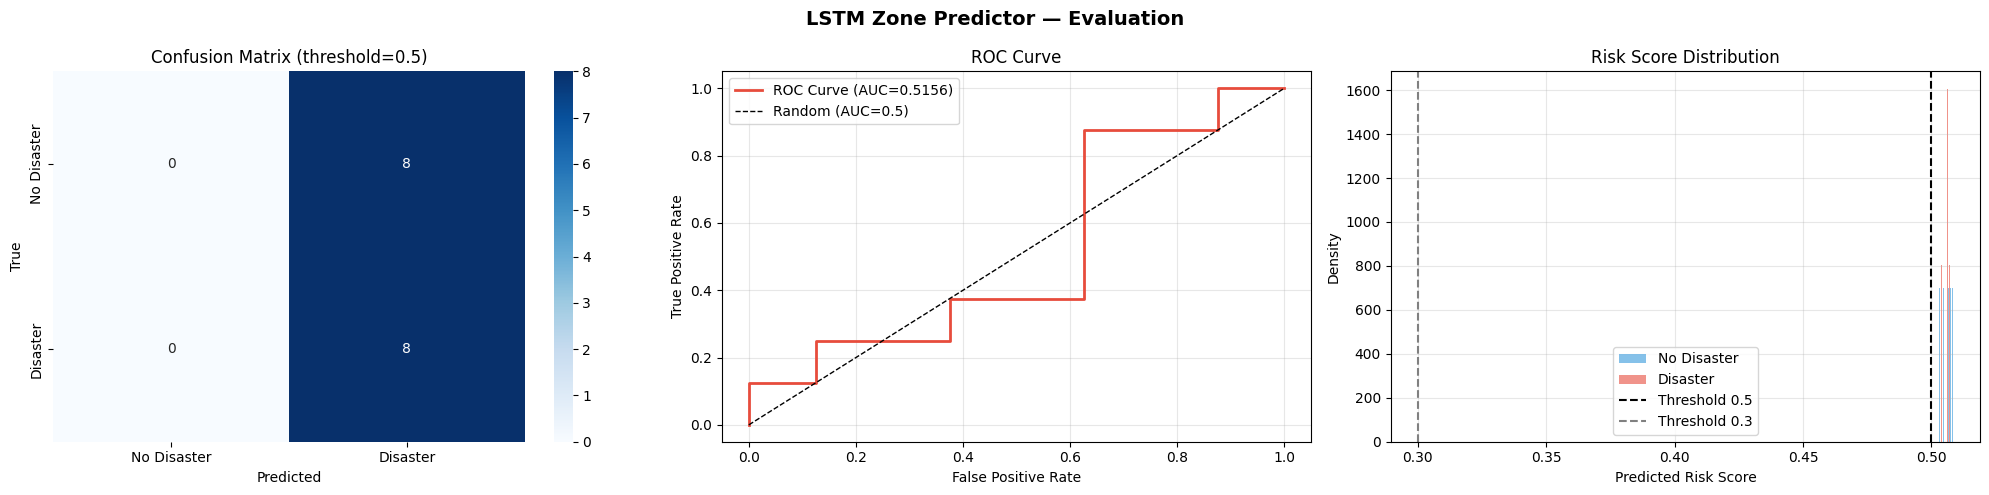

Saved: /content/drive/MyDrive/lstm/results/lstm/lstm_evaluation.png


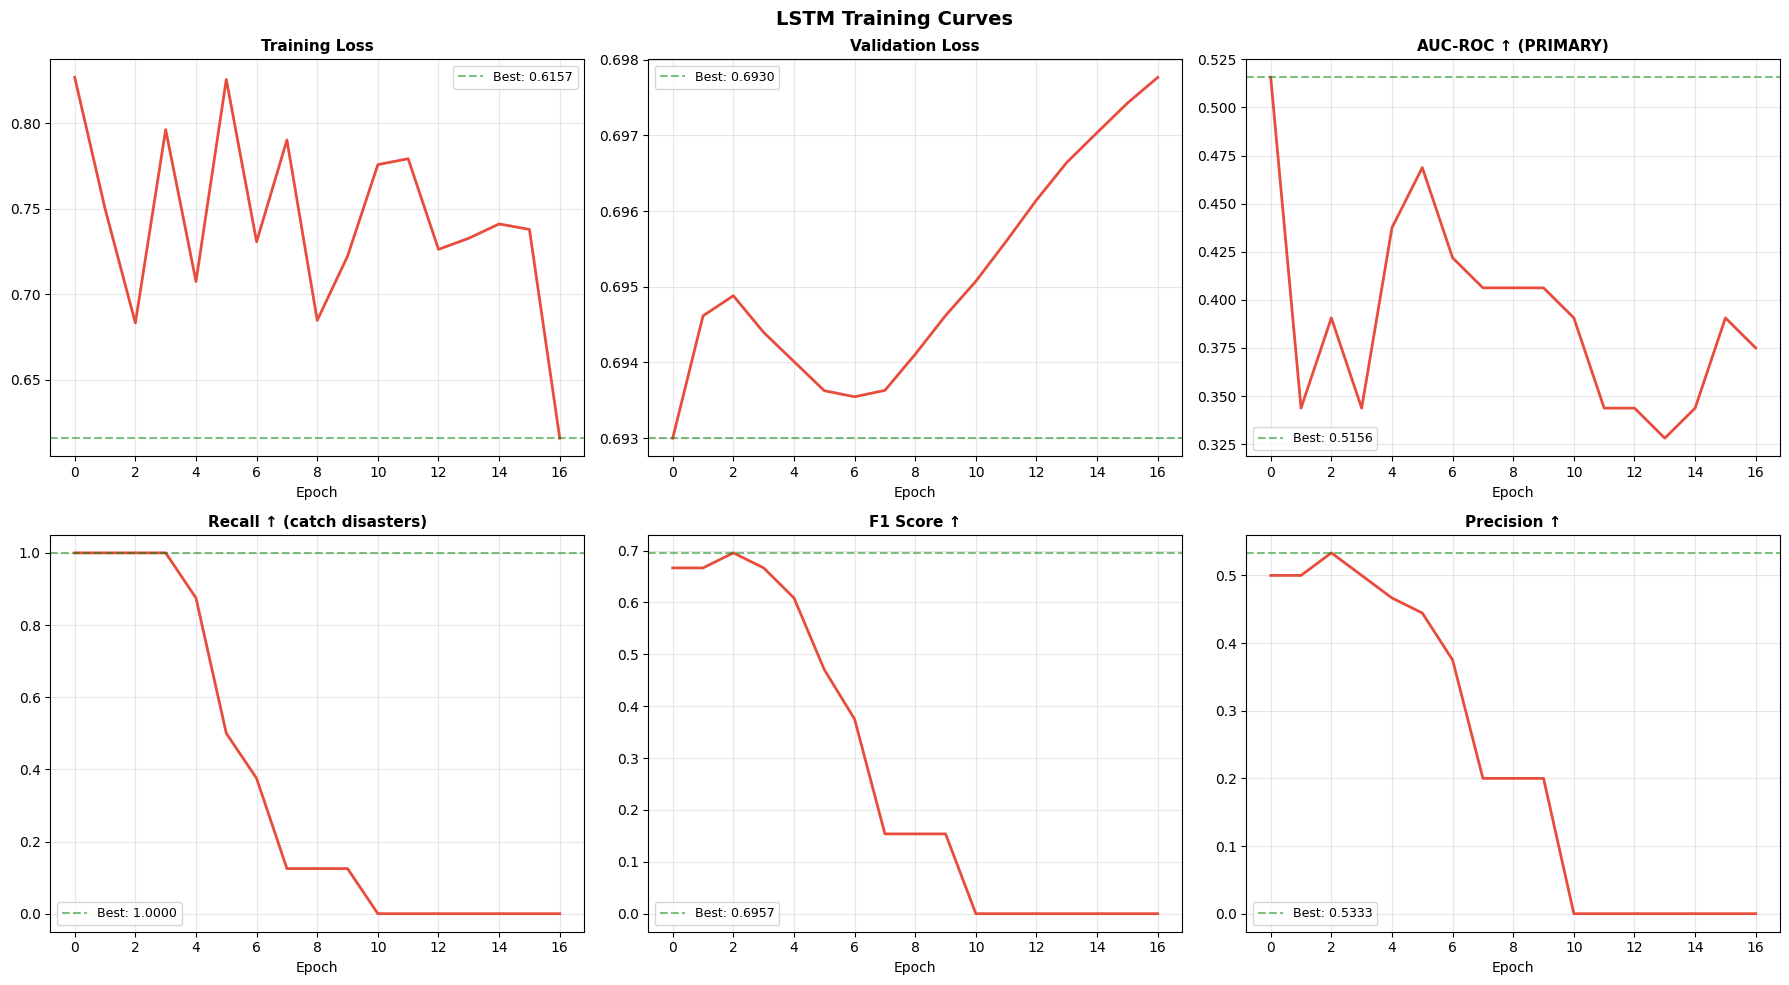

Saved: /content/drive/MyDrive/lstm/results/lstm/lstm_training_curves.png


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 13 — Full Evaluation Report
# ══════════════════════════════════════════════════════════════

import json

# ── Load best checkpoint ──────────────────────────────────────
lstm_ckpt = f'{CHECKPOINT_DIR}/LSTM_ZonePredictor_best.pth'
# Fix applied: weights_only=False to support checkpoint metadata
ckpt_data = torch.load(lstm_ckpt, map_location=device, weights_only=False)

eval_model = ZonePredictorLSTM(
    n_features  = ckpt_data['n_features'],
    hidden_size = ckpt_data['hidden_size'],
    n_layers    = ckpt_data['n_layers']
).to(device)

eval_model.load_state_dict(ckpt_data['model_state'])
eval_model.eval()

print(f'Loaded checkpoint from epoch {ckpt_data["epoch"]}')
print(f'Best AUC-ROC: {ckpt_data["best_auc"]:.4f}')

# ── Run full validation inference ────────────────────────────
all_probs  = []
all_labels = []

with torch.no_grad():
    for seqs, labels in val_loader:
        seqs = seqs.to(device)
        probs = eval_model(seqs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# ── Metrics at multiple thresholds ───────────────────────────
print(f'\n{"="*60}')
print('LSTM EVALUATION REPORT')
print(f'{"="*60}')

print(f'\nMetrics at threshold=0.5 (standard):')
m_05 = compute_lstm_metrics(all_labels, all_probs, threshold=0.5)
for k, v in m_05.items():
    print(f'  {k:<12}: {v:.4f}')

print(f'\nMetrics at threshold=0.3 (higher recall — prefer this for disaster):')
m_03 = compute_lstm_metrics(all_labels, all_probs, threshold=0.3)
for k, v in m_03.items():
    print(f'  {k:<12}: {v:.4f}')

print(f'\nNote: For disaster prediction, RECALL matters more than PRECISION.')
print(f'Missing a disaster (false negative) is far worse than a false alarm.')

# ── Confusion matrix ─────────────────────────────────────────
y_pred_05 = (all_probs >= 0.5).astype(int)
cm = confusion_matrix(all_labels, y_pred_05)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('LSTM Zone Predictor — Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=['No Disaster','Disaster'],
            yticklabels=['No Disaster','Disaster'],
            cmap='Blues')
axes[0].set_title('Confusion Matrix (threshold=0.5)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
auc = roc_auc_score(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Risk score distribution
axes[2].hist(all_probs[all_labels==0], bins=30, alpha=0.6,
             color='#3498db', label='No Disaster', density=True)
axes[2].hist(all_probs[all_labels==1], bins=30, alpha=0.6,
             color='#e74c3c', label='Disaster', density=True)
axes[2].axvline(0.5, color='black', ls='--', label='Threshold 0.5')
axes[2].axvline(0.3, color='gray',  ls='--', label='Threshold 0.3')
axes[2].set_xlabel('Predicted Risk Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Risk Score Distribution', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/lstm_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/lstm_evaluation.png')

# ── Training history plots ────────────────────────────────────
history_path = f'{CHECKPOINT_DIR}/LSTM_ZonePredictor_history.json'
if os.path.exists(history_path):
    with open(history_path) as f:
        hist = json.load(f)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('LSTM Training Curves', fontsize=14, fontweight='bold')

    plots = [
        ('train_loss', 'Training Loss', False),
        ('val_loss',   'Validation Loss', False),
        ('auc_roc',    'AUC-ROC ↑ (PRIMARY)', True),
        ('recall',     'Recall ↑ (catch disasters)', True),
        ('f1',         'F1 Score ↑', True),
        ('precision',  'Precision ↑', True),
    ]

    for ax, (key, title, higher) in zip(axes.flat, plots):
        vals = hist.get(key, [])
        if vals:
            ax.plot(vals, color='#e74c3c', lw=2)
            best = max(vals) if higher else min(vals)
            ax.axhline(best, color='green', ls='--', alpha=0.5,
                       label=f'Best: {best:.4f}')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/lstm_training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {RESULTS_DIR}/lstm_training_curves.png')

Risk predictions for 16 zones:
                  zone  risk_score risk_level  true_label  event_type
1   morocco-earthquake      0.5085     MEDIUM           1  earthquake
9   morocco-nodisaster      0.5082     MEDIUM           0        none
7        congo-volcano      0.5080     MEDIUM           1     volcano
8    turkey-nodisaster      0.5077     MEDIUM           0        none
13    chile-nodisaster      0.5076     MEDIUM           0        none
0    turkey-earthquake      0.5075     MEDIUM           1  earthquake
15   brazil-nodisaster      0.5073     MEDIUM           0        none
2          libya-flood      0.5069     MEDIUM           1       flood
4       bata-explosion      0.5065     MEDIUM           1   explosion
5     la-palma-volcano      0.5064     MEDIUM           1     volcano
6     haiti-earthquake      0.5063     MEDIUM           1  earthquake
3      hawaii-wildfire      0.5062     MEDIUM           1    wildfire
10    libya-nodisaster      0.5060     MEDIUM           0  

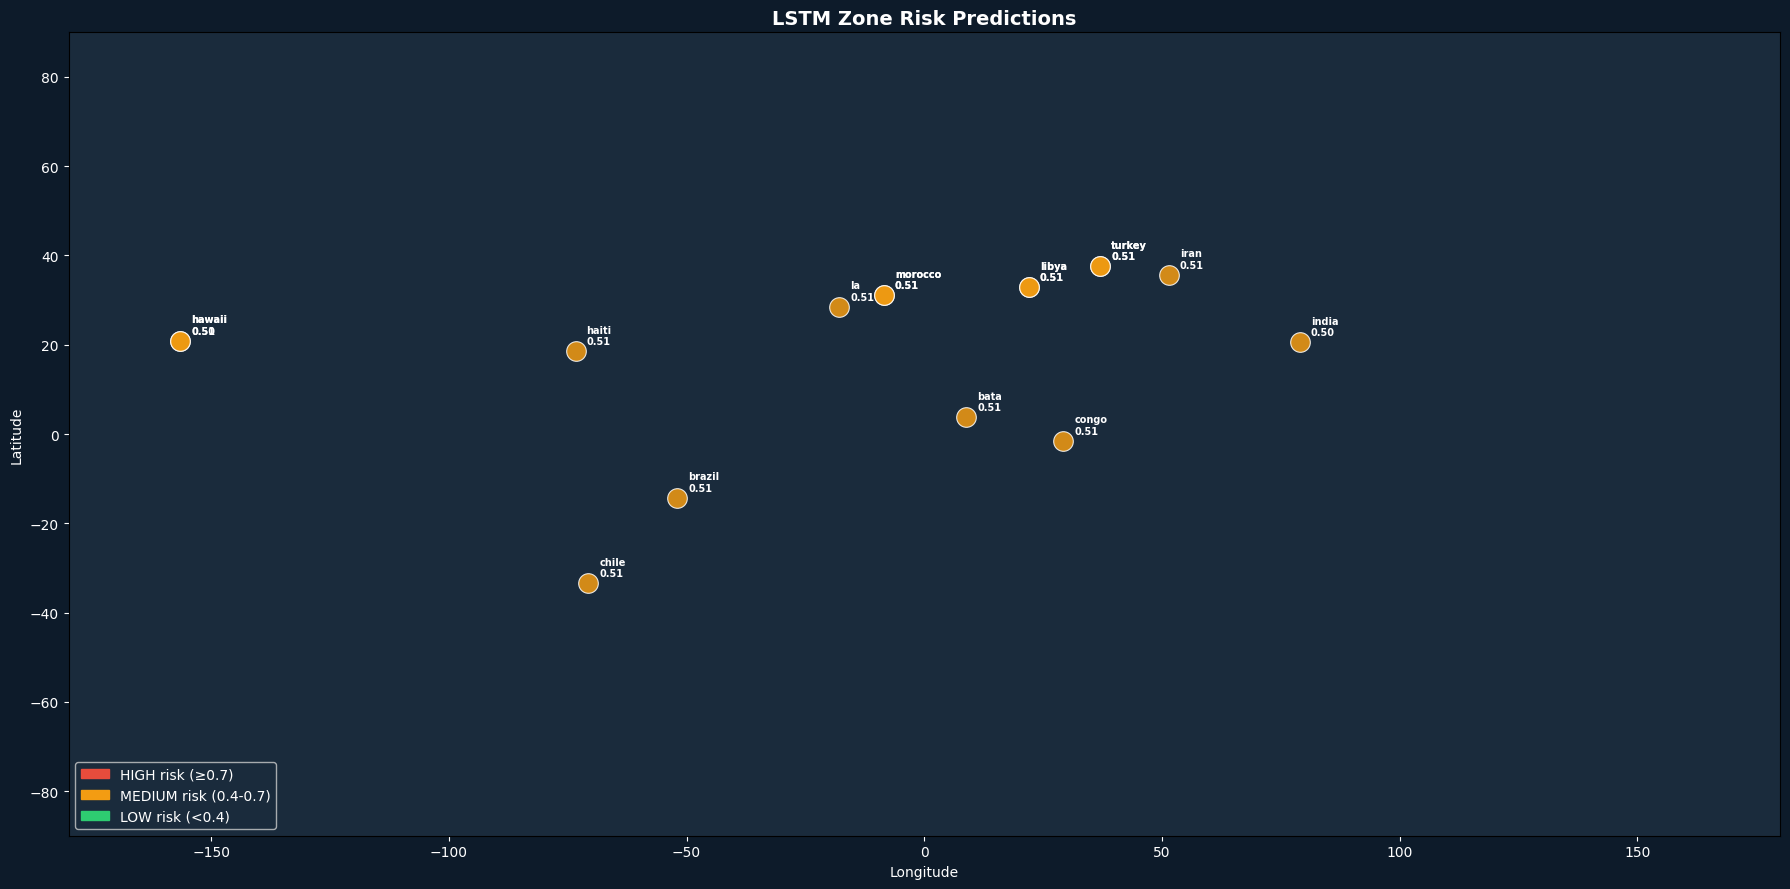

Saved: /content/drive/MyDrive/lstm/results/lstm/zone_risk_map.png
Saved: /content/drive/MyDrive/lstm/results/lstm/zone_risk_predictions.csv


In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 14 — Visualise Risk Scores on World Map
# ══════════════════════════════════════════════════════════════

def predict_zone_risk(model, scaler, zone_info_dict,
                       weather_cache, seismic_cache,
                       feature_cols, lookback=30):
    """
    Runs the LSTM on all zones and returns risk scores.
    Used for the dashboard risk heatmap.
    """
    model.eval()
    results = []

    for zone_name, zone_info in zone_info_dict.items():
        if zone_name not in weather_cache:
            continue

        w_df = weather_cache[zone_name]
        s_df = seismic_cache.get(zone_name, pd.DataFrame())

        if len(s_df) == 0:
            s_df = pd.DataFrame({
                'date': w_df['date'],
                'quake_count': 0, 'max_magnitude': 0.0,
                'mean_magnitude': 0.0, 'total_energy': 0.0,
                'depth_mean': 0.0
            })

        engineered = engineer_features(w_df, s_df)

        available = [c for c in feature_cols if c in engineered.columns]
        feat_mat  = engineered[available].values.astype(np.float32)

        if len(feat_mat) < lookback:
            continue

        # Use last lookback days
        seq = feat_mat[-lookback:]

        # Normalize using training scaler
        seq_scaled = scaler.transform(seq)

        seq_tensor = torch.from_numpy(
            seq_scaled[np.newaxis].astype(np.float32)
        ).to(device)

        with torch.no_grad():
            risk_score = model(seq_tensor).item()

        results.append({
            'zone':        zone_name,
            'latitude':    zone_info['lat'],
            'longitude':   zone_info['lon'],
            'risk_score':  risk_score,
            'true_label':  1 if zone_info['type'] != 'none' else 0,
            'event_type':  zone_info['type'],
            'risk_level':  'HIGH' if risk_score >= 0.7 else
                           'MEDIUM' if risk_score >= 0.4 else 'LOW'
        })

    return pd.DataFrame(results)


# Load scaler
import pickle
with open(f'{CHECKPOINT_DIR}/lstm_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Run predictions
risk_df = predict_zone_risk(
    model         = eval_model,
    scaler        = scaler,
    zone_info_dict = DISASTER_ZONES,
    weather_cache = weather_cache,
    seismic_cache = seismic_cache,
    feature_cols  = FEATURE_COLS,
    lookback      = LOOKBACK
)

print(f'Risk predictions for {len(risk_df)} zones:')
print(risk_df[['zone','risk_score','risk_level','true_label','event_type']]
      .sort_values('risk_score', ascending=False)
      .round(4).to_string())

# ── World map visualisation ───────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 9))

# Background
ax.set_facecolor('#1a2b3c')
fig.patch.set_facecolor('#0d1b2a')

# Plot zones
colors_map = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#2ecc71'}
sizes_map  = {'HIGH': 300, 'MEDIUM': 200, 'LOW': 150}

for _, row in risk_df.iterrows():
    color  = colors_map[row['risk_level']]
    size   = sizes_map[row['risk_level']]
    marker = '★' if row['true_label'] == 1 else 'o'
    ax.scatter(
        row['longitude'], row['latitude'],
        s=size, c=color, alpha=0.85,
        edgecolors='white', linewidths=0.8,
        zorder=5
    )
    ax.annotate(
        f"{row['zone'].split('-')[0]}\n{row['risk_score']:.2f}",
        (row['longitude'], row['latitude']),
        textcoords='offset points', xytext=(8, 5),
        fontsize=7, color='white', fontweight='bold'
    )

# Legend
legend_elements = [
    mpatches.Patch(color='#e74c3c', label='HIGH risk (≥0.7)'),
    mpatches.Patch(color='#f39c12', label='MEDIUM risk (0.4-0.7)'),
    mpatches.Patch(color='#2ecc71', label='LOW risk (<0.4)'),
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=10, facecolor='#1a2b3c', labelcolor='white')

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.tick_params(colors='white')
ax.set_title('LSTM Zone Risk Predictions',
             color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/zone_risk_map.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'Saved: {RESULTS_DIR}/zone_risk_map.png')

# Save risk predictions to CSV
risk_df.to_csv(f'{RESULTS_DIR}/zone_risk_predictions.csv', index=False)
print(f'Saved: {RESULTS_DIR}/zone_risk_predictions.csv')

In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 15 — Export Model for Production
#
# Exports to ONNX + saves scaler + generates model card
# Everything the production system needs in one place
# ══════════════════════════════════════════════════════════════

# Fix: Install onnxruntime and onnxscript which are missing from the environment
!pip install -q onnxruntime onnxscript

import onnxruntime
import time
import pickle
import json

# ── Load best model ───────────────────────────────────────────
lstm_ckpt = f'{CHECKPOINT_DIR}/LSTM_ZonePredictor_best.pth'
# Fix applied: weights_only=False for compatibility with metadata
ckpt_data = torch.load(lstm_ckpt, map_location='cpu', weights_only=False)

prod_model = ZonePredictorLSTM(
    n_features  = ckpt_data['n_features'],
    hidden_size = ckpt_data['hidden_size'],
    n_layers    = ckpt_data['n_layers']
)
prod_model.load_state_dict(ckpt_data['model_state'])
prod_model.eval()

print(f'Model loaded: epoch {ckpt_data["epoch"]}, '
      f'AUC={ckpt_data["best_auc"]:.4f}')

# ── Export to ONNX ────────────────────────────────────────────
onnx_path = f'{CHECKPOINT_DIR}/LSTM_ZonePredictor.onnx'
dummy_input = torch.randn(1, LOOKBACK, N_FEATURES)

print('Exporting to ONNX...')
torch.onnx.export(
    prod_model,
    dummy_input,
    onnx_path,
    opset_version = 17,
    input_names   = ['sequence'],
    output_names  = ['risk_score'],
    dynamic_axes  = {
        'sequence':   {0: 'batch_size'},
        'risk_score': {0: 'batch_size'}
    }
)
print(f'ONNX exported: {onnx_path}')

# ── Validate ONNX ─────────────────────────────────────────────
test_input = torch.randn(4, LOOKBACK, N_FEATURES)

with torch.no_grad():
    pt_out = prod_model(test_input).numpy()

sess    = onnxruntime.InferenceSession(onnx_path)
ort_out = sess.run(None, {'sequence': test_input.numpy()})[0]

max_diff = np.abs(pt_out - ort_out).max()
print(f'ONNX validation: max_diff={max_diff:.8f} '
      f'{"✅ PASS" if max_diff < 1e-4 else "❌ FAIL"}')

# ── Benchmark ─────────────────────────────────────────────────
n_runs = 500
inp    = torch.randn(1, LOOKBACK, N_FEATURES)

t0 = time.time()
with torch.no_grad():
    for _ in range(n_runs):
        prod_model(inp)
pt_ms = (time.time() - t0) * 1000 / n_runs

t0 = time.time()
for _ in range(n_runs):
    sess.run(None, {'sequence': inp.numpy()})
ort_ms = (time.time() - t0) * 1000 / n_runs

print(f'PyTorch: {pt_ms:.2f}ms/call')
print(f'ONNX:    {ort_ms:.2f}ms/call')
print(f'Speedup: {pt_ms/ort_ms:.2f}x')

# ── Generate model card ───────────────────────────────────────
model_card = {
    'model_name':    'LSTM_ZonePredictor',
    'version':       '1.0',
    'task':          'Binary classification — disaster risk prediction',
    'architecture':  f'Stacked LSTM (hidden={ckpt_data["hidden_size"]}, layers={ckpt_data["n_layers"]})',
    'input_shape':   f'(batch, {LOOKBACK}, {N_FEATURES})',
    'output_shape':  '(batch,)  — risk score 0-1',
    'features':      FEATURE_COLS,
    'n_features':    N_FEATURES,
    'lookback_days': LOOKBACK,
    'horizon_days':  HORIZON,
    'best_auc_roc':  ckpt_data['best_auc'],
    'trained_epoch': ckpt_data['epoch'],
    'val_metrics':   ckpt_data['metrics'],
    'data_sources':  ['Open-Meteo (weather)', 'USGS (seismic)', 'GDACS (disaster records)'],
    'training_zones': list(DISASTER_ZONES.keys()),
    'threshold_recommended': 0.3,
    'note': 'Use threshold=0.3 for deployment — higher recall is preferred over precision for disaster prediction',
    'files': {
        'checkpoint': lstm_ckpt,
        'onnx':       onnx_path,
        'scaler':     f'{CHECKPOINT_DIR}/lstm_scaler.pkl'
    }
}

card_path = f'{CHECKPOINT_DIR}/LSTM_model_card.json'
with open(card_path, 'w') as f:
    json.dump(model_card, f, indent=2, default=str)

print(f'\nModel card saved: {card_path}')

# ── Summary ───────────────────────────────────────────────────
print(f'\n{"="*60}')
print('LSTM TRAINING COMPLETE')
print(f'{"="*60}')
print(f'Best AUC-ROC:   {ckpt_data["best_auc"]:.4f}')
print(f'Recall:         {ckpt_data["metrics"]["recall"]:.4f}')
print(f'Precision:      {ckpt_data["metrics"]["precision"]:.4f}')
print(f'F1:             {ckpt_data["metrics"]["f1"]:.4f}')
print(f'\nFiles saved to: {CHECKPOINT_DIR}')
print(f'  .pth checkpoint:  LSTM_ZonePredictor_best.pth')
print(f'  .onnx model:      LSTM_ZonePredictor.onnx')
print(f'  scaler:           lstm_scaler.pkl')
print(f'  model card:       LSTM_model_card.json')
print(f'\nResults saved to: {RESULTS_DIR}')
print(f'  lstm_evaluation.png')
print(f'  lstm_training_curves.png')
print(f'  zone_risk_map.png')
print(f'  zone_risk_predictions.csv')
print(f'{"="*60}')

# ── Download files ────────────────────────────────────────────
print('\nDownloading checkpoint files...')
from google.colab import files
files.download(lstm_ckpt)
files.download(onnx_path)
files.download(f'{CHECKPOINT_DIR}/lstm_scaler.pkl')
files.download(card_path)
print('Download initiated. Check your browser downloads folder.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 16.1 MB/s eta 0:00:00
Model loaded: epoch 1, AUC=0.5156
Exporting to ONNX...


W0607 08:10:12.034000 2676 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ZonePredictorLSTM([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ZonePredictorLSTM([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX exported: /content/drive/MyDrive/lstm/models/checkpoints/LSTM_ZonePredictor.onnx
ONNX validation: max_diff=0.00000000 ✅ PASS
PyTorch: 1.09ms/call
ONNX:    0.49ms/call
Speedup: 2.25x

Model card saved: /content/drive/MyDrive/lstm/models/checkpoints/LSTM_model_card.json

LSTM TRAINING COMPLETE
Best AUC-ROC:   0.5156
Recall:         1.0000
Precision:      0.5000
F1:             0.6667

Files saved to: /content/drive/MyDrive/lstm/models/checkpoints
  .pth checkpoint:  LSTM_ZonePredictor_best.pth
  .onnx model:      LSTM_ZonePredictor.onnx
  scaler:           lstm_scaler.pkl
  model card:       LSTM_model_card.json

Results saved to: /content/drive/MyDrive/lstm/results/lstm
  lstm_evaluation.png
  lstm_training_curves.png
  zone_risk_map.png
  zone_risk_predictions.csv



<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated. Check your browser downloads folder.
